In [1]:
import tensorflow as tf

In [2]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

In [3]:
from sklearn.model_selection import train_test_split

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
train_dir = "C:\\Users\\sureb\\Plant_Disease_Dataset\\train"
train_dir

'C:\\Users\\sureb\\Plant_Disease_Dataset\\train'

In [5]:
class_names = [dir for dir in os.listdir(train_dir) if os.path.isdir(train_dir+"/"+dir)]
class_names

['Apple - Apple Scab',
 'Apple - Healthy',
 'Bell Pepper - Bacterial Spot',
 'Bell Pepper - Healthy',
 'Cherry - Healthy',
 'Cherry - Powdery Mildew',
 'Corn (Maize) - Cercospora Leaf Spot',
 'Corn (Maize) - Healthy',
 'Grape - Black Rot',
 'Grape - Healthy',
 'Peach - Bacterial Spot',
 'Peach - Healthy',
 'Potato - Early Blight',
 'Potato - Healthy',
 'Strawberry - Healthy',
 'Strawberry - Leaf Scorch',
 'Tomato - Healthy',
 'Tomato - Septoria Leaf Spot']

In [6]:
import glob

In [7]:
filenames_train = list(glob.glob(train_dir+"/*/*.jpg"))
filenames_train[0]

'C:\\Users\\sureb\\Plant_Disease_Dataset\\train\\Apple - Apple Scab\\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'

In [8]:
print("Total no.of images present in Dataset: {}".format(len(filenames_train)))

Total no.of images present in Dataset: 33113


In [9]:
categories_train = []
for filename in filenames_train:
  category = filename.split("\\")[-2]
  categories_train.append(category)
     

In [10]:
train_df = pd.DataFrame({
    "filename": filenames_train,
    "category": categories_train
})
    

In [11]:
train_df.head()

,filename,category
0,C:\Users\sureb\Plant_Disease_Dataset\train\App...,Apple - Apple Scab
1,C:\Users\sureb\Plant_Disease_Dataset\train\App...,Apple - Apple Scab
2,C:\Users\sureb\Plant_Disease_Dataset\train\App...,Apple - Apple Scab
3,C:\Users\sureb\Plant_Disease_Dataset\train\App...,Apple - Apple Scab
4,C:\Users\sureb\Plant_Disease_Dataset\train\App...,Apple - Apple Scab


In [12]:
train_df.shape

(33113, 2)

<Axes: xlabel='category'>

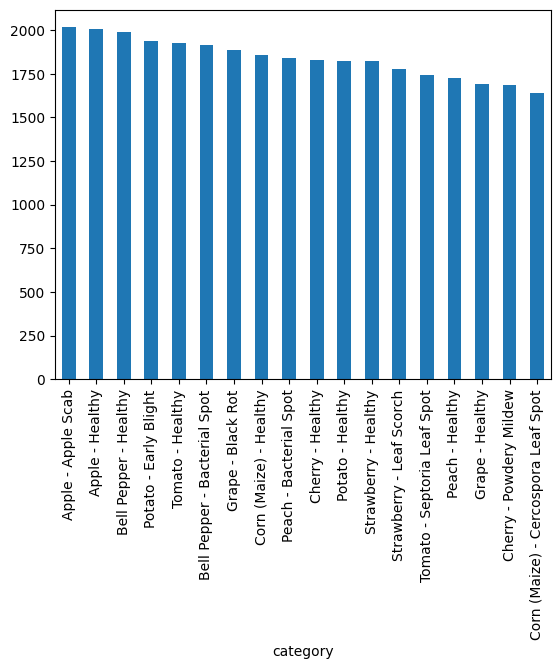

In [13]:
train_df['category'].value_counts().plot.bar()

In [14]:
test_dir = "C:\\Users\\sureb\\Plant_Disease_Dataset\\valid"
test_dir

'C:\\Users\\sureb\\Plant_Disease_Dataset\\valid'

In [15]:
filenames_test = list(glob.glob(test_dir+"/*/*.jpg"))
filenames_test[0]

'C:\\Users\\sureb\\Plant_Disease_Dataset\\valid\\Apple - Apple Scab\\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335_270deg.JPG'

In [16]:
print("Total no.of images present in Dataset: {}".format(len(filenames_test)))

Total no.of images present in Dataset: 7440


In [17]:
categories_test = []
for filename in filenames_test:
  category = filename.split("\\")[-2]
  categories_test.append(category)

In [18]:
test_df = pd.DataFrame({
    "filename": filenames_test,
    "category": categories_test
})
    

In [19]:
train_length = train_df.shape[0]
test_length = test_df.shape[0]

In [20]:
print (train_length)
print (test_length)

33113
7440


# Data augmentation

In [21]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range = 20,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip = True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    preprocessing_function = preprocess_input
)

In [22]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    train_dir+"/*/",
    x_col='filename',
    y_col='category',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size = 32
)

Found 33113 validated image filenames belonging to 18 classes.


In [23]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [24]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    test_dir+"/*/",
    x_col='filename',
    y_col='category',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size = 32
)

Found 7440 validated image filenames belonging to 18 classes.


In [25]:
import h5py
print(h5py.__version__)

3.9.0


In [26]:
mobilenet = MobileNetV2(input_shape=[224, 224, 3], weights='imagenet', include_top=False)

In [27]:
for layer in mobilenet.layers:
  layer.trainable = False

In [28]:
x = tf.keras.layers.GlobalAveragePooling2D()(mobilenet.output)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

In [29]:
model = tf.keras.models.Model(inputs=mobilenet.input, outputs=x)

In [30]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [31]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), 
    optimizer='adam',
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    train_generator,
    epochs=10,
    steps_per_epoch = train_length//32,
    validation_data=test_generator,
    validation_steps=test_length//32,
    callbacks = tf.keras.callbacks.EarlyStopping(patience=3)
)

Epoch 1/10
1034/1034 [==============================] - 311s 296ms/step - loss: 0.2470 - accuracy: 0.9225 - val_loss: 0.1305 - val_accuracy: 0.9562
Epoch 2/10
1034/1034 [==============================] - 305s 295ms/step - loss: 0.1338 - accuracy: 0.9563 - val_loss: 0.0787 - val_accuracy: 0.9735
Epoch 3/10
1034/1034 [==============================] - 326s 316ms/step - loss: 0.1179 - accuracy: 0.9619 - val_loss: 0.0907 - val_accuracy: 0.9705
Epoch 4/10
1034/1034 [==============================] - 308s 298ms/step - loss: 0.1081 - accuracy: 0.9652 - val_loss: 0.0786 - val_accuracy: 0.9763
Epoch 5/10
1034/1034 [==============================] - 301s 291ms/step - loss: 0.1002 - accuracy: 0.9687 - val_loss: 0.0841 - val_accuracy: 0.9732
Epoch 6/10
1034/1034 [==============================] - 300s 291ms/step - loss: 0.0968 - accuracy: 0.9708 - val_loss: 0.1123 - val_accuracy: 0.9665
Epoch 7/10
1034/1034 [==============================] - 304s 294ms/step - loss: 0.0970 - accuracy: 0.9704 - val_

In [33]:
## model evaluation on testing set 
test_loss, test_acc= model.evaluate(test_generator)
print(test_loss, test_acc)

233/233 [==============================] - 12s 48ms/step - loss: 0.0520 - accuracy: 0.9833
0.05195131152868271 0.9833333492279053


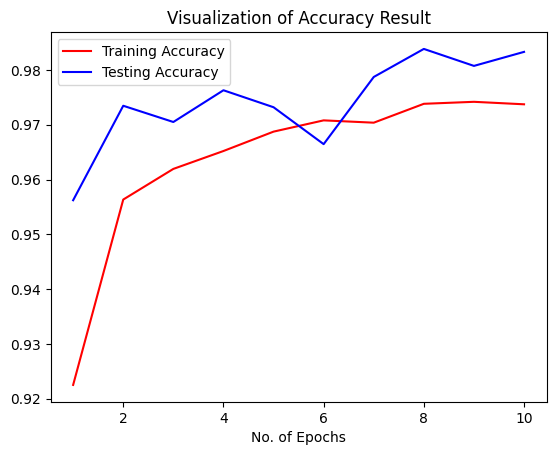

In [34]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,history.history['val_accuracy'],color='blue',label='Testing Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result') plt.legend() plt.show()

In [35]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    test_dir+"/*/",
    x_col='filename',
    y_col='category',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False  # important to match predictions with true labels
)

Found 7440 validated image filenames belonging to 18 classes.


In [36]:
y_pred_prob = model.predict(
    test_generator,
    steps=np.ceil(test_generator.samples / test_generator.batch_size)
)


233/233 [==============================] - 11s 44ms/step


In [37]:
predicted_indices = np.argmax(y_pred_prob, axis=1)

In [38]:
y_true = test_generator.classes  # integers

In [39]:
inv_map = {v: k for k, v in test_generator.class_indices.items()}
class_names_ordered = [inv_map[i] for i in range(len(inv_map))]

In [40]:
predicted_labels = [inv_map[i] for i in predicted_indices]

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

In [42]:
print("Classification Report:\n")
print(classification_report(y_true, predicted_indices, target_names=class_names_ordered))


Classification Report:

                                     precision    recall  f1-score   support

                 Apple - Apple Scab       0.99      0.95      0.97       453
                    Apple - Healthy       0.98      0.98      0.98       451
       Bell Pepper - Bacterial Spot       0.95      0.99      0.97       430
              Bell Pepper - Healthy       0.98      0.96      0.97       447
                   Cherry - Healthy       0.98      1.00      0.99       410
            Cherry - Powdery Mildew       0.99      0.99      0.99       378
Corn (Maize) - Cercospora Leaf Spot       1.00      1.00      1.00       369
             Corn (Maize) - Healthy       1.00      1.00      1.00       418
                  Grape - Black Rot       1.00      0.98      0.99       424
                    Grape - Healthy       0.97      1.00      0.99       380
             Peach - Bacterial Spot       0.99      0.98      0.98       413
                    Peach - Healthy       0.95     

In [43]:
# 7. Confusion matrix
cm = confusion_matrix(y_true, predicted_indices)

In [46]:
import seaborn as sns

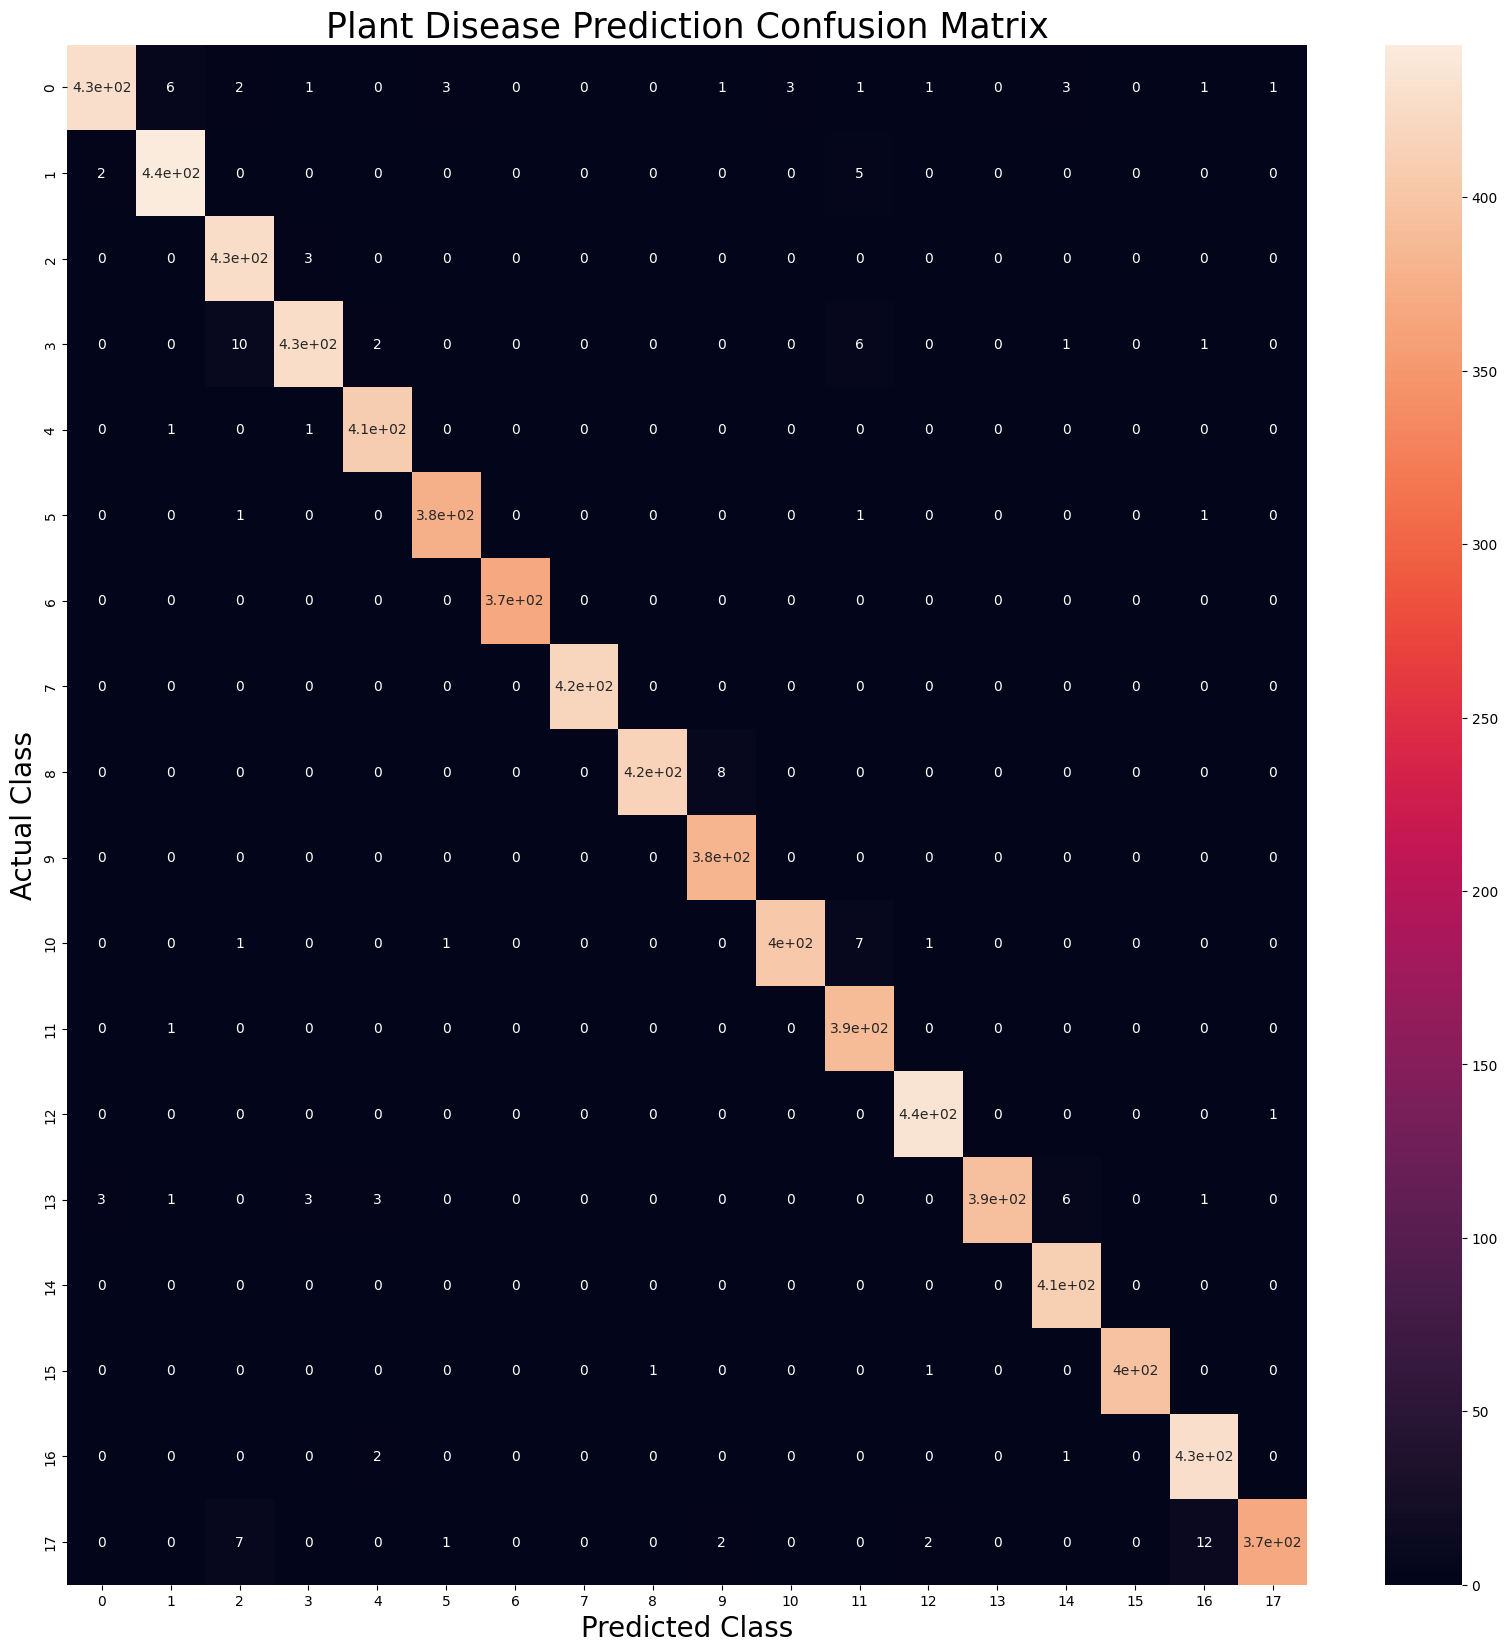

In [49]:
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot= True, annot_kws= {'size':10})
plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()